# PUSGD Model

In [22]:
import numpy as np
import scipy.sparse as sp
from sklearn.datasets import fetch_rcv1
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")
np.random.seed(0)

# Estimating $c_k$ for each label using Elkan & Noto's approach

In [23]:
def estimate_c_per_label(X, S, random_state=42):
    n, q = S.shape
    c_est = np.zeros(q, dtype=float)
    for k in range(q):
        s_k = S[:, k]
        vals = np.unique(s_k)
        if len(vals) < 2:
            c_est[k] = 1.0 if vals[0] == 1 else 0.0
        else:
            clf = LogisticRegression(random_state=random_state, max_iter=1000)
            clf.fit(X, s_k)
            pos = (s_k == 1)
            if pos.sum() == 0:
                c_est[k] = 0.0
            else:
                c_est[k] = clf.predict_proba(X[pos])[:, 1].mean()
    return c_est

# Custom PU logistic regression for binary labels $\{0,1\}$

In [24]:
def pu_logistic_loss_sgd_binary(X, s, c=0.5, lr=0.01, n_epochs=5, random_state=42):

    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape
    w = rng.normal(scale=0.01, size=n_features)

    for _ in range(n_epochs):
        idx = rng.permutation(n_samples)
        for i in idx:
            xi = X[i]
            si = s[i]
            z = w.dot(xi)
            σ = 1.0 / (1.0 + np.exp(-z))
            if si == 1:
                grad = -(1 - σ) * xi
            else:
                denom = 1 - c * σ + 1e-8
                grad = (c * σ * (1 - σ) / denom) * xi
            w -= lr * grad
    return w

In [25]:
class CustomPULogRegBinary:
    def __init__(self, c=0.5, lr=0.01, n_epochs=5, random_state=42):
        self.c = c
        self.lr = lr
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.w = None

    def fit(self, X, s):
        # convert sparse → dense
        if sp.issparse(X):
            X = X.toarray()
        self.w = pu_logistic_loss_sgd_binary(
            X, s, c=self.c, lr=self.lr,
            n_epochs=self.n_epochs,
            random_state=self.random_state
        )
        return self

    def predict_proba(self, X):
        if sp.issparse(X):
            X = X.toarray()
        σ = 1.0 / (1.0 + np.exp(-X.dot(self.w)))
        # P(s=1) = c * σ
        p1 = self.c * σ
        p0 = 1.0 - p1
        return np.vstack([p0, p1]).T

# Cross-Validation for out‑of‑fold predictions

In [26]:
def cross_validation_predictions(X, s, make_model, n_folds=3, random_state=42):
    n = X.shape[0]
    P_hat = np.zeros(n, dtype=float)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    for tr_idx, te_idx in kf.split(range(n)):
        model = make_model()
        model.fit(X[tr_idx], s[tr_idx])
        P_hat[te_idx] = model.predict_proba(X[te_idx])[:, 1]
    return P_hat

# MPU training (L stacking level)

In [27]:
def mpu_train(X, S, c_values, L=1, n_folds=3, random_state=42):

    n, q = S.shape
    X_curr = X
    all_models = []

    # Level 0: base models
    base_models = []
    for k in range(q):
        def make_base():
            return CustomPULogRegBinary(
                c=c_values[k], lr=0.01, n_epochs=5,
                random_state=random_state
            )

        m0 = make_base().fit(X_curr, S[:, k])
        base_models.append(m0)
    all_models.append(base_models)

    
    for level in range(1, L+1):
        # get OOF preds for X_curr
        P_stack = np.zeros((n, q))
        for k in range(q):
            def make_model_k():
                return CustomPULogRegBinary(
                    c=c_values[k], lr=0.01, n_epochs=5,
                    random_state=random_state
                )
            P_stack[:, k] = cross_validation_predictions(
                X_curr, S[:, k], make_model_k,
                n_folds=n_folds, random_state=random_state
            )
        # extend features
        if sp.issparse(X_curr):
            X_curr = sp.hstack([X_curr, sp.csr_matrix(P_stack)], format="csr")
        else:
            X_curr = np.hstack([X_curr, P_stack])

        # train next level models
        lvl_models = []
        for k in range(q):
            mk = CustomPULogRegBinary(
                c=c_values[k], lr=0.01, n_epochs=5,
                random_state=random_state
            ).fit(X_curr, S[:, k])
            lvl_models.append(mk)
        all_models.append(lvl_models)

    return all_models

# MPU inference

In [28]:
def mpu_predict(all_models, X_test):

    X_curr = X_test
    for lvl, models in enumerate(all_models):
        n, _ = X_curr.shape
        q = len(models)
        P_lvl = np.zeros((n, q))
        for k, mk in enumerate(models):
            P_lvl[:, k] = mk.predict_proba(X_curr)[:, 1]
        if lvl < len(all_models) - 1:
            # stack for next level
            if sp.issparse(X_curr):
                X_curr = sp.hstack([X_curr, sp.csr_matrix(P_lvl)], format="csr")
            else:
                X_curr = np.hstack([X_curr, P_lvl])
    return P_lvl

# Simulate incomplete labels

In [29]:
def simulate_incomplete_labels(Y_full, missing_rate=0.5, seed=42):
    rng = np.random.default_rng(seed)
    S = Y_full.copy()
    drop = (rng.random(size=Y_full.shape) < missing_rate)
    S[(Y_full == 1) & drop] = 0
    return S

# Micro‑F1 from the paper

In [30]:
def micro_f1_score(y_true, y_pred):
    inter = np.logical_and(y_true, y_pred).sum()
    p_sum = y_pred.sum()
    t_sum = y_true.sum()
    denom = p_sum + t_sum
    return (2 * inter / denom) if denom > 0 else 0.0

# Loading RCV 1 data

In [5]:
rcv1 = fetch_rcv1()
X_full = rcv1.data
Y_full = rcv1.target.toarray().astype(int)

# Missing Rate 0.4

In [15]:
missing_rate = 0.4
subset = 2700
L = 2

X = X_full[:subset]
Y = Y_full[:subset]
n, q = Y.shape


S = simulate_incomplete_labels(Y, missing_rate=missing_rate, seed=0)


print("Estimating c_k per label...")
c_values = estimate_c_per_label(X, S)


print("Training MPU...")
all_models = mpu_train(X, S, c_values, L=L, n_folds=3)

print("Predicting probabilities...")
P_pred = mpu_predict(all_models, X)
P_pred1 = P_pred / c_values


print("Tuning thresholds per label...")
best_thresh = np.zeros(q)
for k in range(q):
    probs = P_pred1[:, k]
    mn, mx = probs.min(), probs.max()

    grid = np.linspace(mn, mx, num=50)
    best_t, best_f1 = mn, -1
    for t in grid:
        y_hat_k = (probs >= t).astype(int)
        f1 = micro_f1_score(Y[:, k], y_hat_k)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresh[k] = best_t
    
Y_hat = (P_pred1 >= best_thresh).astype(int)
mf1 = micro_f1_score(Y, Y_hat)
# print(f"\nBest thresholds (first 10): {best_thresh[:10]}")
print(f"Final Micro‑F1 = {mf1:.4f}")

Estimating c_k per label...
Training MPU...
Predicting probabilities...
Tuning thresholds per label...

Best thresholds (first 10): [0.34999621 0.37060312 0.33346844 0.48583159 0.28367242 0.20134755
 0.15276041 0.24536795 0.49802838 0.22368318]
Final Micro‑F1 = 0.7951


# Missing Rate 0.5

In [16]:
missing_rate = 0.5
subset = 2700
L = 2


X = X_full[:subset]
Y = Y_full[:subset]
n, q = Y.shape


S = simulate_incomplete_labels(Y, missing_rate=missing_rate, seed=0)


print("Estimating c_k per label...")
c_values = estimate_c_per_label(X, S)


print("Training MPU...")
all_models = mpu_train(X, S, c_values, L=L, n_folds=3)


print("Predicting probabilities...")
P_pred = mpu_predict(all_models, X)
P_pred1 = P_pred / c_values


print("Tuning thresholds per label...")
best_thresh = np.zeros(q)
for k in range(q):
    probs = P_pred1[:, k]
    mn, mx = probs.min(), probs.max()

    grid = np.linspace(mn, mx, num=50)
    best_t, best_f1 = mn, -1
    for t in grid:
        y_hat_k = (probs >= t).astype(int)
        f1 = micro_f1_score(Y[:, k], y_hat_k)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresh[k] = best_t


Y_hat = (P_pred1 >= best_thresh).astype(int)
mf1 = micro_f1_score(Y, Y_hat)
# print(f"\nBest thresholds (first 10): {best_thresh[:10]}")
print(f"Final Micro‑F1 = {mf1:.4f}")

Estimating c_k per label...
Training MPU...
Predicting probabilities...
Tuning thresholds per label...
Final Micro‑F1 = 0.7848


# Missing Rate : 0.6

In [17]:
missing_rate = 0.6
subset = 2700
L = 2

X = X_full[:subset]
Y = Y_full[:subset]
n, q = Y.shape

S = simulate_incomplete_labels(Y, missing_rate=missing_rate, seed=0)

print("Estimating c_k per label...")
c_values = estimate_c_per_label(X, S)

print("Training MPU...")
all_models = mpu_train(X, S, c_values, L=L, n_folds=3)

print("Predicting probabilities...")
P_pred = mpu_predict(all_models, X)
P_pred1 = P_pred / c_values

print("Tuning thresholds per label...")
best_thresh = np.zeros(q)
for k in range(q):
    probs = P_pred1[:, k]
    mn, mx = probs.min(), probs.max()
    grid = np.linspace(mn, mx, num=50)
    best_t, best_f1 = mn, -1
    for t in grid:
        y_hat_k = (probs >= t).astype(int)
        f1 = micro_f1_score(Y[:, k], y_hat_k)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresh[k] = best_t

Y_hat = (P_pred1 >= best_thresh).astype(int)
mf1 = micro_f1_score(Y, Y_hat)
# print(f"\nBest thresholds (first 10): {best_thresh[:10]}")
print(f"Final Micro‑F1 = {mf1:.4f}")

Estimating c_k per label...
Training MPU...
Predicting probabilities...
Tuning thresholds per label...
Final Micro‑F1 = 0.7503


# Missing Rate : 0.7

In [18]:
missing_rate = 0.7
subset = 2700
L = 2


X = X_full[:subset]
Y = Y_full[:subset]
n, q = Y.shape


S = simulate_incomplete_labels(Y, missing_rate=missing_rate, seed=0)


print("Estimating c_k per label...")
c_values = estimate_c_per_label(X, S)


print("Training MPU...")
all_models = mpu_train(X, S, c_values, L=L, n_folds=3)


print("Predicting probabilities...")
P_pred = mpu_predict(all_models, X)
P_pred1 = P_pred / c_values


print("Tuning thresholds per label...")
best_thresh = np.zeros(q)
for k in range(q):
    probs = P_pred1[:, k]
    mn, mx = probs.min(), probs.max()

    grid = np.linspace(mn, mx, num=50)
    best_t, best_f1 = mn, -1
    for t in grid:
        y_hat_k = (probs >= t).astype(int)
        f1 = micro_f1_score(Y[:, k], y_hat_k)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresh[k] = best_t

    # final binary predictions & micro‑F1
Y_hat = (P_pred1 >= best_thresh).astype(int)
mf1 = micro_f1_score(Y, Y_hat)

print(f"Final Micro‑F1 = {mf1:.4f}")

Estimating c_k per label...
Training MPU...
Predicting probabilities...
Tuning thresholds per label...
Final Micro‑F1 = 0.7019


# Missing Rate : 0.8

In [19]:
missing_rate = 0.8
subset = 2700
L = 2


X = X_full[:subset]
Y = Y_full[:subset]
n, q = Y.shape


S = simulate_incomplete_labels(Y, missing_rate=missing_rate, seed=0)


print("Estimating c_k per label...")
c_values = estimate_c_per_label(X, S)


print("Training MPU...")
all_models = mpu_train(X, S, c_values, L=L, n_folds=3)


print("Predicting probabilities...")
P_pred = mpu_predict(all_models, X)
P_pred1 = P_pred / c_values


print("Tuning thresholds per label...")
best_thresh = np.zeros(q)
for k in range(q):
    probs = P_pred1[:, k]
    mn, mx = probs.min(), probs.max()

    grid = np.linspace(mn, mx, num=50)
    best_t, best_f1 = mn, -1
    for t in grid:
        y_hat_k = (probs >= t).astype(int)
        f1 = micro_f1_score(Y[:, k], y_hat_k)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresh[k] = best_t


Y_hat = (P_pred1 >= best_thresh).astype(int)
mf1 = micro_f1_score(Y, Y_hat)
# print(f"\nBest thresholds (first 10): {best_thresh[:10]}")
print(f"Final Micro‑F1 = {mf1:.4f}")

Estimating c_k per label...
Training MPU...
Predicting probabilities...
Tuning thresholds per label...
Final Micro‑F1 = 0.5937


# Final Result


# Micro F1 Scores for Different Missing Rates (Obtained from Our Code)

The following table shows the corresponding Micro F1 scores we obtained for each missing rate:

| **Missing Rate** | **Micro F1 (Obtained)** |
|------------------|-------------------------|
| $0.4$            | $0.7951$                |
| $0.5$            | $0.7848$                |
| $0.6$            | $0.7503$                |
| $0.7$            | $0.7019$                |
| $0.8$            | $0.5937$                |


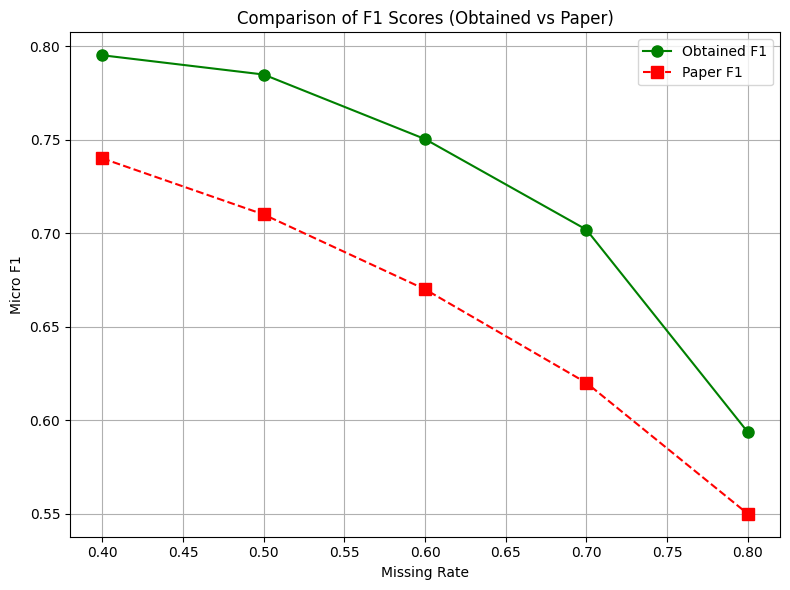

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns


obtained_f1 = [0.7951, 0.7848, 0.7503, 0.7019, 0.5937]
missing_rates = [0.4, 0.5, 0.6, 0.7, 0.8]
paper_f1 = [0.74, 0.71, 0.67, 0.62, 0.55]


plt.figure(figsize=(8, 6))


plt.plot(missing_rates, obtained_f1, marker='o', color='green', label='Obtained F1', linestyle='-', markersize=8)


plt.plot(missing_rates, paper_f1, marker='s', color='red', label='Paper F1', linestyle='--', markersize=8)


plt.xlabel('Missing Rate')
plt.ylabel('Micro F1')
plt.title('Comparison of F1 Scores (Obtained vs Paper)')
plt.legend()


plt.grid(True)
plt.tight_layout()
plt.show()
